In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0032.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0026.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0040.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0056.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0009.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0011.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0018.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0005.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0051.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0014.npy
/kaggle/input/datasets/jorgeoc

In [2]:
import os
import glob

root = "/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2"

print("Subcarpetas:")
for p in glob.glob(os.path.join(root, "*")):
    print(p)

print("\nArchivos quality:")
for p in glob.glob(os.path.join(root, "quality_dataset", "*"))[:20]:
    print(p)

print("\nArchivos restoration:")
for p in glob.glob(os.path.join(root, "restoration_dataset", "*"))[:20]:
    print(p)

Subcarpetas:
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset

Archivos quality:
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/X_0032.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/meta_0049.json
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/Qlabel_0025.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/Qscore_0046.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/meta_0032.json
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/meta_0036.json
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/Qscore_

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/jorgeoc
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset


In [4]:

# =========================
# CELDA 1: Dataset calidad
# =========================
import os
import glob
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

ROOT = "/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2"
QDIR = os.path.join(ROOT, "quality_dataset")

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

X_files = sorted(glob.glob(os.path.join(QDIR, "X_*.npy")))
Qscore_files = sorted(glob.glob(os.path.join(QDIR, "Qscore_*.npy")))
Qlabel_files = sorted(glob.glob(os.path.join(QDIR, "Qlabel_*.npy")))

print("QDIR:", QDIR)
print("quality shards X:", len(X_files))
print("quality shards Qscore:", len(Qscore_files))
print("quality shards Qlabel:", len(Qlabel_files))
print("Ejemplo X:", X_files[:3])
print("Ejemplo Qscore:", Qscore_files[:3])
print("Ejemplo Qlabel:", Qlabel_files[:3])

if len(X_files) == 0 or len(Qscore_files) == 0 or len(Qlabel_files) == 0:
    raise FileNotFoundError(f"No se encontraron shards de quality en {QDIR}")

# prueba rápida
x0 = np.load(X_files[0], mmap_mode="r")
s0 = np.load(Qscore_files[0], mmap_mode="r")
l0 = np.load(Qlabel_files[0], mmap_mode="r")

print("x0 shape:", x0.shape, x0.dtype)
print("s0 shape:", s0.shape, s0.dtype, "min/max:", float(s0.min()), float(s0.max()))
print("l0 shape:", l0.shape, l0.dtype, "pos frac:", float(l0.mean()))

class ShardedQualityDataset(Dataset):
    def __init__(self, X_files, Qscore_files, Qlabel_files, max_per_shard=None, seed=123):
        self.samples = []
        rng = np.random.default_rng(seed)

        for xf, sf, lf in zip(X_files, Qscore_files, Qlabel_files):
            X = np.load(xf, mmap_mode="r")
            n = len(X)
            idx = np.arange(n)

            if max_per_shard is not None and n > max_per_shard:
                idx = rng.choice(idx, size=max_per_shard, replace=False)

            for i in idx:
                self.samples.append((xf, sf, lf, int(i)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        xf, sf, lf, i = self.samples[idx]
        X = np.load(xf, mmap_mode="r")
        S = np.load(sf, mmap_mode="r")
        L = np.load(lf, mmap_mode="r")

        x = torch.tensor(X[i], dtype=torch.float32)
        s = torch.tensor([S[i]], dtype=torch.float32)  # score continuo
        l = torch.tensor([L[i]], dtype=torch.float32)  # label binaria
        return x, s, l

def split_files(files, frac_val=0.15, seed=123):
    idx = np.arange(len(files))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    n_val = max(1, int(len(files) * frac_val))
    return idx[n_val:], idx[:n_val]

def mse_np(a, b):
    return float(np.mean((a - b) ** 2))

def mae_np(a, b):
    return float(np.mean(np.abs(a - b)))

def binary_metrics_from_probs(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    y_pred = (y_prob >= thr).astype(np.int32)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    acc = (tp + tn) / max(len(y_true), 1)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-8)
    return {
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn
    }

   

QDIR: /kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset
quality shards X: 57
quality shards Qscore: 57
quality shards Qlabel: 57
Ejemplo X: ['/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/X_0000.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/X_0001.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/X_0002.npy']
Ejemplo Qscore: ['/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/Qscore_0000.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/Qscore_0001.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/Qscore_0002.npy']
Ejemplo Qlabel: ['/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/quality_dataset/Qlabel_0000.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_

In [5]:
# =========================
# CELDA 2: Modelo calidad
# =========================
class QualityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.head_score = nn.Linear(32, 1)  # regresión
        self.head_label = nn.Linear(32, 1)  # clasificación binaria

    def forward(self, x):
        z = self.features(x)
        z = self.shared(z)
        q_score = torch.sigmoid(self.head_score(z))
        q_logit = self.head_label(z)
        return q_score, q_logit

In [6]:
# =========================
# CELDA 3: Entrenamiento
# =========================
idx_tr, idx_val = split_files(X_files, frac_val=0.15, seed=SEED)

train_ds = ShardedQualityDataset(
    [X_files[i] for i in idx_tr],
    [Qscore_files[i] for i in idx_tr],
    [Qlabel_files[i] for i in idx_tr],
    max_per_shard=4000,
    seed=1
)

val_ds = ShardedQualityDataset(
    [X_files[i] for i in idx_val],
    [Qscore_files[i] for i in idx_val],
    [Qlabel_files[i] for i in idx_val],
    max_per_shard=4000,
    seed=2
)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = QualityNet().to(device)

bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    loss_sum, n = 0.0, 0
    y_score_true, y_score_pred = [], []
    y_label_true, y_label_prob = [], []

    for x, s, l in loader:
        x = x.to(device)
        s = s.to(device)
        l = l.to(device)

        ps, qlogit = model(x)
        loss = 0.7 * mse(ps, s) + 0.3 * bce(qlogit, l)

        loss_sum += loss.item() * x.size(0)
        n += x.size(0)

        y_score_true.append(s.cpu().numpy().reshape(-1))
        y_score_pred.append(ps.cpu().numpy().reshape(-1))
        y_label_true.append(l.cpu().numpy().reshape(-1))
        y_label_prob.append(torch.sigmoid(qlogit).cpu().numpy().reshape(-1))

    y_score_true = np.concatenate(y_score_true)
    y_score_pred = np.concatenate(y_score_pred)
    y_label_true = np.concatenate(y_label_true)
    y_label_prob = np.concatenate(y_label_prob)

    mets_bin = binary_metrics_from_probs(y_label_true, y_label_prob, thr=0.5)
    mets = {
        "loss": loss_sum / max(n, 1),
        "score_mse": mse_np(y_score_true, y_score_pred),
        "score_mae": mae_np(y_score_true, y_score_pred),
        **mets_bin
    }
    return mets, y_score_true, y_score_pred, y_label_true, y_label_prob

history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": [], "val_score_mae": []}

best_state = None
best_score = -1
patience = 5
bad_epochs = 0
EPOCHS = 25

for ep in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    n_seen = 0
    t0 = time.time()

    for x, s, l in train_loader:
        x = x.to(device)
        s = s.to(device)
        l = l.to(device)

        opt.zero_grad()
        ps, qlogit = model(x)
        loss = 0.7 * mse(ps, s) + 0.3 * bce(qlogit, l)
        loss.backward()
        opt.step()

        train_loss_sum += loss.item() * x.size(0)
        n_seen += x.size(0)

    train_loss = train_loss_sum / max(n_seen, 1)
    val_mets, st, sp, lt, lp = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_mets["loss"])
    history["val_f1"].append(val_mets["f1"])
    history["val_acc"].append(val_mets["acc"])
    history["val_score_mae"].append(val_mets["score_mae"])

    score = 0.5 * val_mets["f1"] + 0.5 * (1 - val_mets["score_mae"])

    print(
        f"Epoch {ep:02d} | train_loss={train_loss:.4f} | val_loss={val_mets['loss']:.4f} | "
        f"f1={val_mets['f1']:.4f} | acc={val_mets['acc']:.4f} | "
        f"score_mae={val_mets['score_mae']:.4f} | score_mse={val_mets['score_mse']:.4f} | "
        f"time={time.time()-t0:.1f}s"
    )

    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
torch.save(model.state_dict(), "/kaggle/working/quality_judge_best.pt")
print("Guardado: /kaggle/working/quality_judge_best.pt")

device: cuda
Epoch 01 | train_loss=0.0954 | val_loss=0.0822 | f1=0.8268 | acc=0.9048 | score_mae=0.0992 | score_mse=0.0185 | time=1110.7s
Epoch 02 | train_loss=0.0706 | val_loss=0.0733 | f1=0.8452 | acc=0.9143 | score_mae=0.0854 | score_mse=0.0154 | time=1074.0s
Epoch 03 | train_loss=0.0646 | val_loss=0.0673 | f1=0.8565 | acc=0.9228 | score_mae=0.0816 | score_mse=0.0141 | time=1083.7s
Epoch 04 | train_loss=0.0613 | val_loss=0.0656 | f1=0.8617 | acc=0.9247 | score_mae=0.0823 | score_mse=0.0138 | time=1092.3s
Epoch 05 | train_loss=0.0594 | val_loss=0.0624 | f1=0.8664 | acc=0.9277 | score_mae=0.0766 | score_mse=0.0123 | time=1073.3s
Epoch 06 | train_loss=0.0574 | val_loss=0.0611 | f1=0.8726 | acc=0.9289 | score_mae=0.0755 | score_mse=0.0123 | time=1104.5s
Epoch 07 | train_loss=0.0559 | val_loss=0.0610 | f1=0.8679 | acc=0.9300 | score_mae=0.0753 | score_mse=0.0121 | time=1138.6s
Epoch 08 | train_loss=0.0549 | val_loss=0.0611 | f1=0.8740 | acc=0.9296 | score_mae=0.0756 | score_mse=0.0123 | 

Métricas finales calidad: {'loss': 0.050912034407258035, 'score_mse': 0.010209276340901852, 'score_mae': 0.06788112968206406, 'acc': 0.94178125, 'precision': 0.8957069528698087, 'recall': 0.8879380131837632, 'f1': 0.8918055636215808, 'tp': 7678, 'tn': 22459, 'fp': 894, 'fn': 969}


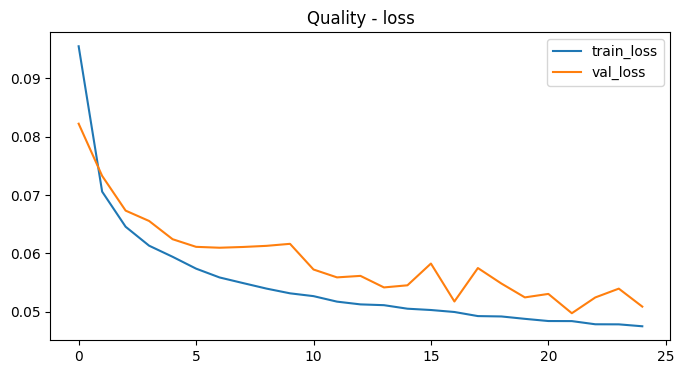

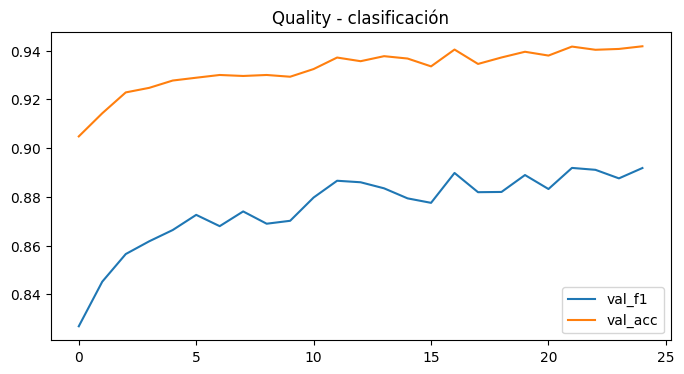

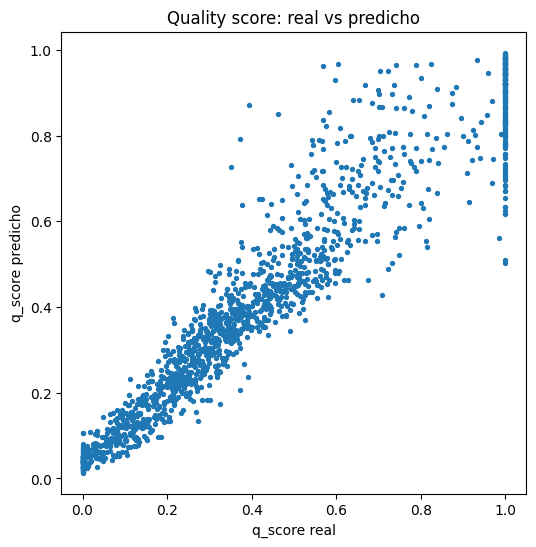

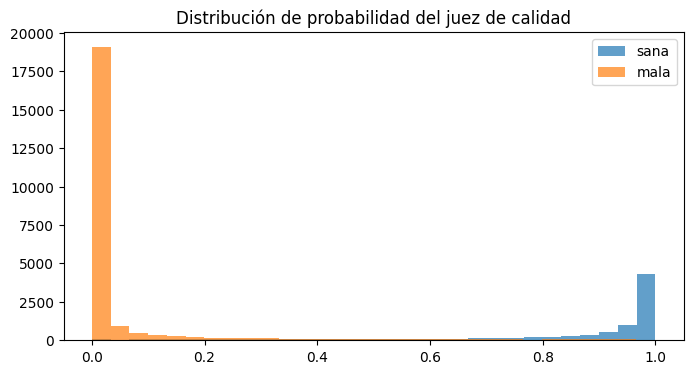

In [7]:
# =========================
# CELDA 4: Gráficas calidad
# =========================
val_mets, st, sp, lt, lp = evaluate(val_loader)
print("Métricas finales calidad:", val_mets)

plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Quality - loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["val_f1"], label="val_f1")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Quality - clasificación")
plt.legend()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(st[:1500], sp[:1500], s=8)
plt.xlabel("q_score real")
plt.ylabel("q_score predicho")
plt.title("Quality score: real vs predicho")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(lp[lt == 1], bins=30, alpha=0.7, label="sana")
plt.hist(lp[lt == 0], bins=30, alpha=0.7, label="mala")
plt.legend()
plt.title("Distribución de probabilidad del juez de calidad")
plt.show()